In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc, RocCurveDisplay
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("badcodebuilder/insdn-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/insdn-dataset


In [3]:
import os

# List the files in the dataset directory
print("Files in path:", os.listdir(path))


Files in path: ['InSDN_DatasetCSV']


In [4]:
import os
import pandas as pd

# Define the full path to the folder containing the CSV
folder_path = "/kaggle/input/insdn-dataset/InSDN_DatasetCSV"

# List files inside that folder to find the CSV file name
print("Files in subfolder:", os.listdir(folder_path))


Files in subfolder: ['metasploitable-2.csv', 'Normal_data.csv', 'OVS.csv']


In [5]:
csv_file_path = os.path.join(folder_path, 'filename.csv')

# Load the CSV into a pandas DataFrame
df1 = pd.read_csv("/kaggle/input/insdn-dataset/InSDN_DatasetCSV/metasploitable-2.csv")
df1


,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,192.168.3.130-200.175.2.130-38694-4444-6,192.168.3.130,38694,200.175.2.130,4444,6,10/1/2020 5:02,269709,4,5,...,0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,U2R
1,192.168.3.130-200.175.2.130-38693-4444-6,192.168.3.130,38693,200.175.2.130,4444,6,10/1/2020 5:02,268599,2,3,...,0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,U2R
2,192.168.3.130-200.175.2.130-3632-33747-6,200.175.2.130,33747,192.168.3.130,3632,6,10/1/2020 5:02,22194,5,5,...,0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,U2R
3,192.168.3.130-200.175.2.130-8180-38745-6,200.175.2.130,38745,192.168.3.130,8180,6,10/1/2020 1:39,9556,4,4,...,0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,BFA
4,192.168.3.130-200.175.2.130-8180-37217-6,200.175.2.130,37217,192.168.3.130,8180,6,10/1/2020 1:39,8782,4,4,...,0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,BFA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
136738,192.168.3.130-200.175.2.130-41966-4444-6,192.168.3.130,41966,200.175.2.130,4444,6,10/1/2020 20:36,273133,2,3,...,0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,U2R
136739,192.168.3.130-200.175.2.130-41967-4444-6,192.168.3.130,41967,200.175.2.130,4444,6,10/1/2020 20:36,267969,6,7,...,0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,U2R
136740,192.168.3.130-200.175.2.130-139-44791-6,200.175.2.130,44791,192.168.3.130,139,6,10/1/2020 4:41,1552555,6,5,...,0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,U2R
136741,192.168.3.130-200.175.2.130-41966-4444-6,192.168.3.130,41966,200.175.2.130,4444,6,10/1/2020 4:41,272141,2,3,...,0,0.0,0.0,0,0,0.0,0.0,0.0,0.0,U2R


In [6]:
csv_file_path = os.path.join(folder_path, 'filename.csv')

# Load the CSV into a pandas DataFrame
df2 = pd.read_csv("/kaggle/input/insdn-dataset/InSDN_DatasetCSV/Normal_data.csv")
df2

,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,185.127.17.56-192.168.20.133-443-53648-6,185.127.17.56,443,192.168.20.133,53648,6,5/2/2020 13:58,245230,44,40,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Normal
1,185.127.17.56-192.168.20.133-443-53650-6,192.168.20.133,53650,185.127.17.56,443,6,5/2/2020 13:58,1605449,107,149,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Normal
2,192.168.20.133-192.168.20.2-35108-53-6,192.168.20.133,35108,192.168.20.2,53,6,5/2/2020 13:58,53078,5,5,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Normal
3,192.168.20.133-192.168.20.2-35108-53-6,192.168.20.2,53,192.168.20.133,35108,6,5/2/2020 13:58,6975,1,1,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Normal
4,154.59.122.74-192.168.20.133-443-60900-6,192.168.20.133,60900,154.59.122.74,443,6,5/2/2020 13:58,190141,13,16,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68419,185.127.17.56-192.168.20.133-443-36100-6,192.168.20.133,36100,185.127.17.56,443,6,5/2/2020 19:20,1895,0,2,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Normal
68420,192.168.20.133-192.168.20.2-53032-53-17,192.168.20.133,53032,192.168.20.2,53,17,5/2/2020 19:21,3842,1,3,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Normal
68421,192.168.20.133-192.168.20.2-39285-53-17,192.168.20.133,39285,192.168.20.2,53,17,5/2/2020 19:19,3731,1,3,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Normal
68422,192.168.20.133-192.168.20.2-49895-53-17,192.168.20.133,49895,192.168.20.2,53,17,5/2/2020 19:18,20591,0,2,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Normal


In [7]:
csv_file_path = os.path.join(folder_path, 'filename.csv')

# Load the CSV into a pandas DataFrame
df3 = pd.read_csv("/kaggle/input/insdn-dataset/InSDN_DatasetCSV/OVS.csv")
df3

,Flow ID,Src IP,Src Port,Dst IP,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,172.17.0.2-200.175.2.130-80-48856-6,200.175.2.130,48856,172.17.0.2,80,6,12/1/2020 1:14,4045,2,5,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BFA
1,172.17.0.2-200.175.2.130-80-48856-6,200.175.2.130,48856,172.17.0.2,80,6,12/1/2020 1:14,284,1,1,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BFA
2,172.17.0.2-200.175.2.130-80-48858-6,200.175.2.130,48858,172.17.0.2,80,6,12/1/2020 1:14,4302,2,5,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BFA
3,172.17.0.2-200.175.2.130-80-48858-6,200.175.2.130,48858,172.17.0.2,80,6,12/1/2020 1:14,83,1,1,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BFA
4,172.17.0.2-200.175.2.130-80-48860-6,200.175.2.130,48860,172.17.0.2,80,6,12/1/2020 1:14,3760,2,5,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,BFA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
138717,172.17.0.2-200.175.2.130-80-55440-6,200.175.2.130,55440,172.17.0.2,80,6,25/12/2019 05:19:55 PM,296,1,1,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Web-Attack
138718,172.17.0.2-200.175.2.130-80-55446-6,200.175.2.130,55446,172.17.0.2,80,6,25/12/2019 05:20:00 PM,3431,2,5,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Web-Attack
138719,172.17.0.2-200.175.2.130-80-55446-6,200.175.2.130,55446,172.17.0.2,80,6,25/12/2019 05:20:00 PM,4121,1,1,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Web-Attack
138720,172.17.0.2-200.175.2.130-80-55456-6,200.175.2.130,55456,172.17.0.2,80,6,25/12/2019 05:20:05 PM,5887,2,5,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Web-Attack


In [8]:
# Merge all datasets
df_combined = pd.concat([df1, df2, df3], ignore_index=True)
print(f"Combined dataset shape: {df_combined.shape}")
print(f"Label distribution:\n{df_combined['Label'].value_counts()}")

Combined dataset shape: (343889, 84)
Label distribution:
Label
Probe         98129
DDoS          73529
Normal        68424
DoS           53616
DDoS          48413
BFA            1405
Web-Attack      192
BOTNET          164
U2R              17
Name: count, dtype: int64


In [9]:
# Combine all datasets
df_combined = pd.concat([df1, df2, df3], ignore_index=True)
print(f"Combined dataset shape: {df_combined.shape}")

# Check label distribution
print("\nLabel distribution:")
print(df_combined['Label'].value_counts())

# Drop unnecessary columns
columns_to_drop = ['Flow ID', 'Src IP', 'Dst IP', 'Timestamp']
df_clean = df_combined.drop(columns=columns_to_drop, errors='ignore')

# Handle infinite and NaN values
df_clean = df_clean.replace([np.inf, -np.inf], np.nan)
df_clean = df_clean.fillna(df_clean.median(numeric_only=True))

# Convert categorical labels to numeric using LabelEncoder
label_encoder = LabelEncoder()
df_clean['Label_Encoded'] = label_encoder.fit_transform(df_clean['Label'])

# Create binary classification (Normal vs Attack)
df_clean['Label_Binary'] = df_clean['Label'].apply(lambda x: 0 if x == 'Normal' else 1)

# Show encoding mapping
print("\nLabel encoding mapping:")
for i, label in enumerate(label_encoder.classes_):
    print(f"{label}: {i}")

# Prepare features and target
X = df_clean.drop(['Label', 'Label_Encoded', 'Label_Binary'], axis=1)
y = df_clean['Label_Binary']

# Convert all features to numeric
X = X.select_dtypes(include=[np.number])

print(f"\nFeatures shape: {X.shape}")
print(f"Target distribution: {np.bincount(y)}")


Combined dataset shape: (343889, 84)

Label distribution:
Label
Probe         98129
DDoS          73529
Normal        68424
DoS           53616
DDoS          48413
BFA            1405
Web-Attack      192
BOTNET          164
U2R              17
Name: count, dtype: int64

Label encoding mapping:
BFA: 0
BOTNET: 1
DDoS: 2
DDoS : 3
DoS: 4
Normal: 5
Probe: 6
U2R: 7
Web-Attack: 8

Features shape: (343889, 79)
Target distribution: [ 68424 275465]


In [10]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")


Training set: (275111, 79)
Test set: (68778, 79)



Training Logistic Regression
Accuracy: 0.9337
ROC AUC: 0.9690

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.79      0.83     13685
           1       0.95      0.97      0.96     55093

    accuracy                           0.93     68778
   macro avg       0.91      0.88      0.89     68778
weighted avg       0.93      0.93      0.93     68778


Training Decision Tree
Accuracy: 0.9998
ROC AUC: 0.9997

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13685
           1       1.00      1.00      1.00     55093

    accuracy                           1.00     68778
   macro avg       1.00      1.00      1.00     68778
weighted avg       1.00      1.00      1.00     68778


Training Random Forest
Accuracy: 0.9999
ROC AUC: 1.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.0

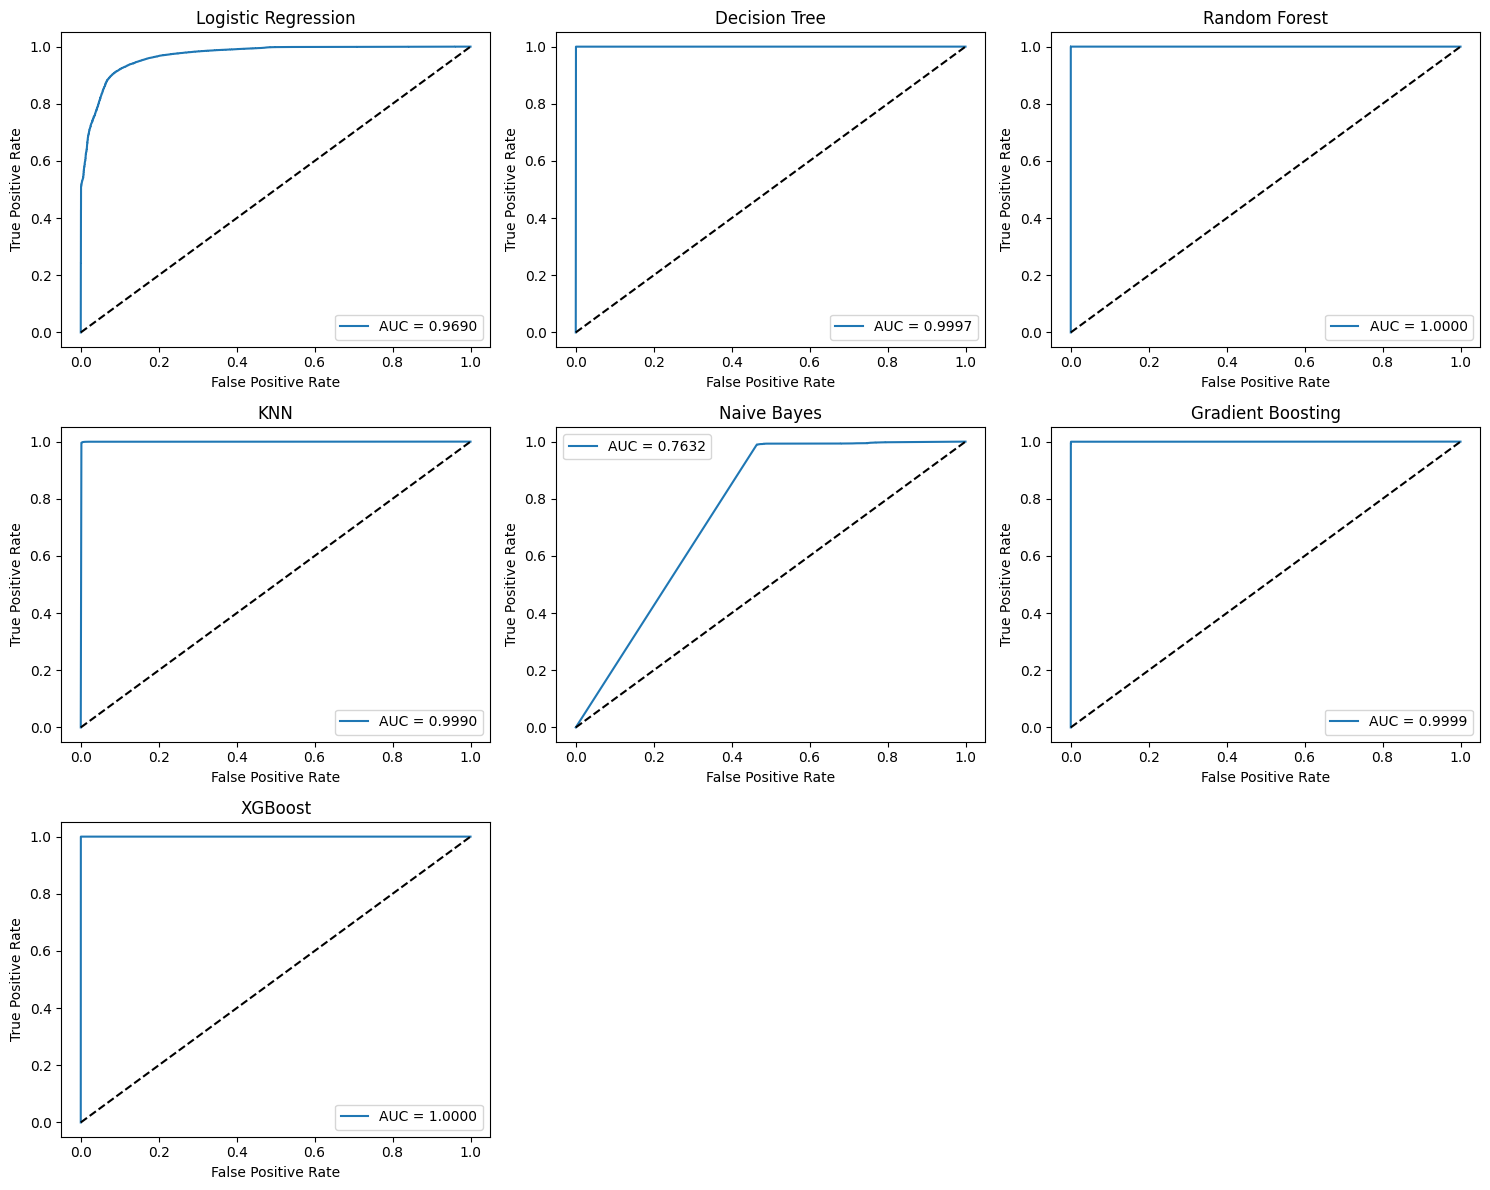

In [11]:
from sklearn.naive_bayes import GaussianNB

# Define models (SVM removed, Naive Bayes added)
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=100),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss')
}

# Train and evaluate models
results = {}
plt.figure(figsize=(15, 12))

for i, (name, model) in enumerate(models.items(), 1):
    print(f"\n{'='*50}")
    print(f"Training {name}")
    print(f"{'='*50}")
    
    # Train model
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)
    
    results[name] = {
        'accuracy': accuracy,
        'roc_auc': roc_auc,
        'model': model
    }
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"ROC AUC: {roc_auc:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred))
    
    # ROC Curve
    plt.subplot(3, 3, i)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.4f}')
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'{name}')
    plt.legend()

plt.tight_layout()
plt.show()


Ensemble Model (XGBoost + LightGBM + CatBoost)


Training Ensemble (XGBoost + LightGBM + CatBoost)
Ensemble Accuracy: 1.0000
Ensemble ROC AUC: 1.0000

Ensemble Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     13685
           1       1.00      1.00      1.00     55093

    accuracy                           1.00     68778
   macro avg       1.00      1.00      1.00     68778
weighted avg       1.00      1.00      1.00     68778



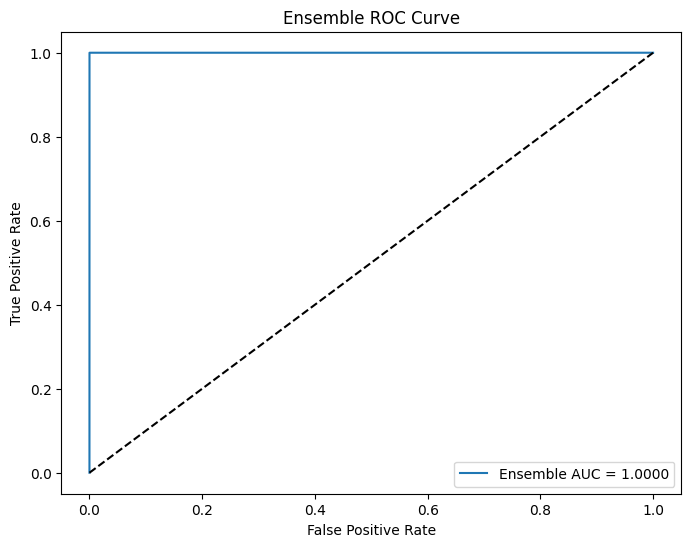

In [12]:
# Create ensemble with XGBoost, LightGBM, and CatBoost
ensemble_models = [
    ('xgb', XGBClassifier(random_state=42, eval_metric='logloss')),
    ('lgb', LGBMClassifier(random_state=42, verbose=-1)),
    ('cat', CatBoostClassifier(random_state=42, verbose=False))
]

ensemble = VotingClassifier(estimators=ensemble_models, voting='soft')

print(f"\n{'='*50}")
print("Training Ensemble (XGBoost + LightGBM + CatBoost)")
print(f"{'='*50}")

# Train ensemble
ensemble.fit(X_train, y_train)

# Predictions
y_pred_ensemble = ensemble.predict(X_test)
y_prob_ensemble = ensemble.predict_proba(X_test)[:, 1]

# Metrics
accuracy_ensemble = accuracy_score(y_test, y_pred_ensemble)
roc_auc_ensemble = roc_auc_score(y_test, y_prob_ensemble)

print(f"Ensemble Accuracy: {accuracy_ensemble:.4f}")
print(f"Ensemble ROC AUC: {roc_auc_ensemble:.4f}")
print(f"\nEnsemble Classification Report:")
print(classification_report(y_test, y_pred_ensemble))

# Plot ensemble ROC
plt.figure(figsize=(8, 6))
fpr, tpr, _ = roc_curve(y_test, y_prob_ensemble)
plt.plot(fpr, tpr, label=f'Ensemble AUC = {roc_auc_ensemble:.4f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Ensemble ROC Curve')
plt.legend()
plt.show()



SHAP Analysis


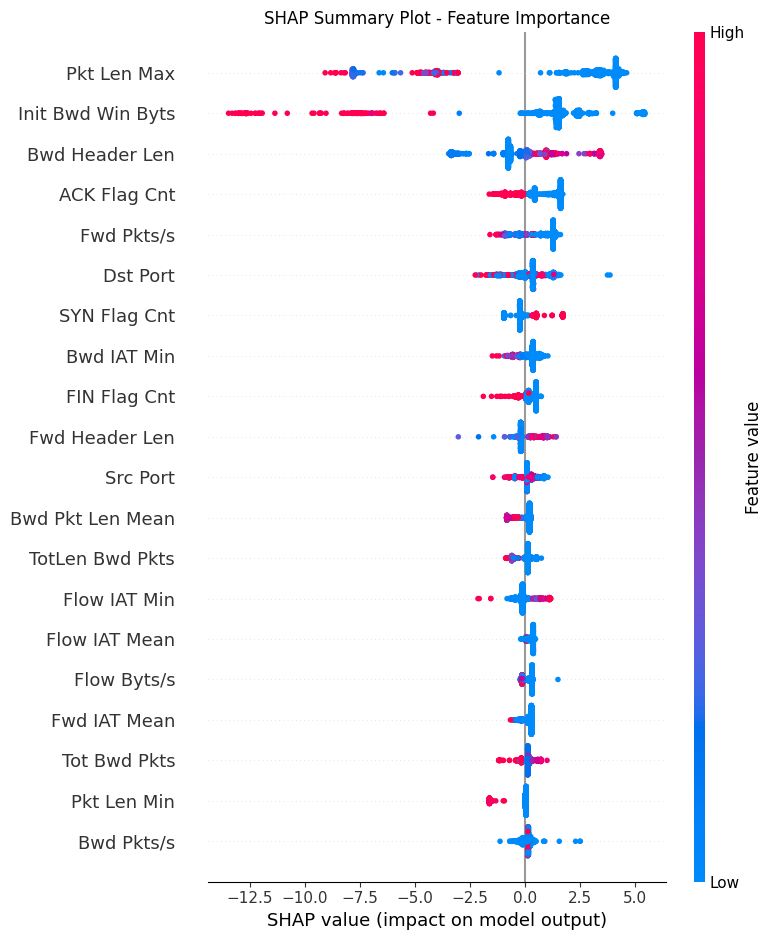


Top 15 Most Important Features:
              feature  importance
41        Pkt Len Max    4.192582
68  Init Bwd Win Byts    2.572981
37     Bwd Header Len    1.108122
49       ACK Flag Cnt    0.962084
38         Fwd Pkts/s    0.925362
1            Dst Port    0.613365
46       SYN Flag Cnt    0.435755
31        Bwd IAT Min    0.389210
45       FIN Flag Cnt    0.334897
36     Fwd Header Len    0.331490
0            Src Port    0.319616
14   Bwd Pkt Len Mean    0.269402
7     TotLen Bwd Pkts    0.268935
21       Flow IAT Min    0.262460
18      Flow IAT Mean    0.238921


In [13]:
import shap

print(f"\n{'='*50}")
print("SHAP Analysis")
print(f"{'='*50}")

# Use XGBoost for SHAP analysis
xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Create SHAP explainer
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test[:1000])

# SHAP summary plot
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test[:1000], show=False)
plt.title('SHAP Summary Plot - Feature Importance')
plt.tight_layout()
plt.show()

# SHAP feature importance
feature_importance = np.abs(shap_values).mean(0)
importance_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("\nTop 15 Most Important Features:")
print(importance_df.head(15))



MODEL COMPARISON SUMMARY
              Model  Accuracy  ROC AUC
            XGBoost  0.999927 0.999998
           Ensemble  0.999956 0.999989
      Random Forest  0.999869 0.999963
  Gradient Boosting  0.999535 0.999886
      Decision Tree  0.999796 0.999681
                KNN  0.997746 0.998985
Logistic Regression  0.933714 0.968979
        Naive Bayes  0.899125 0.763186


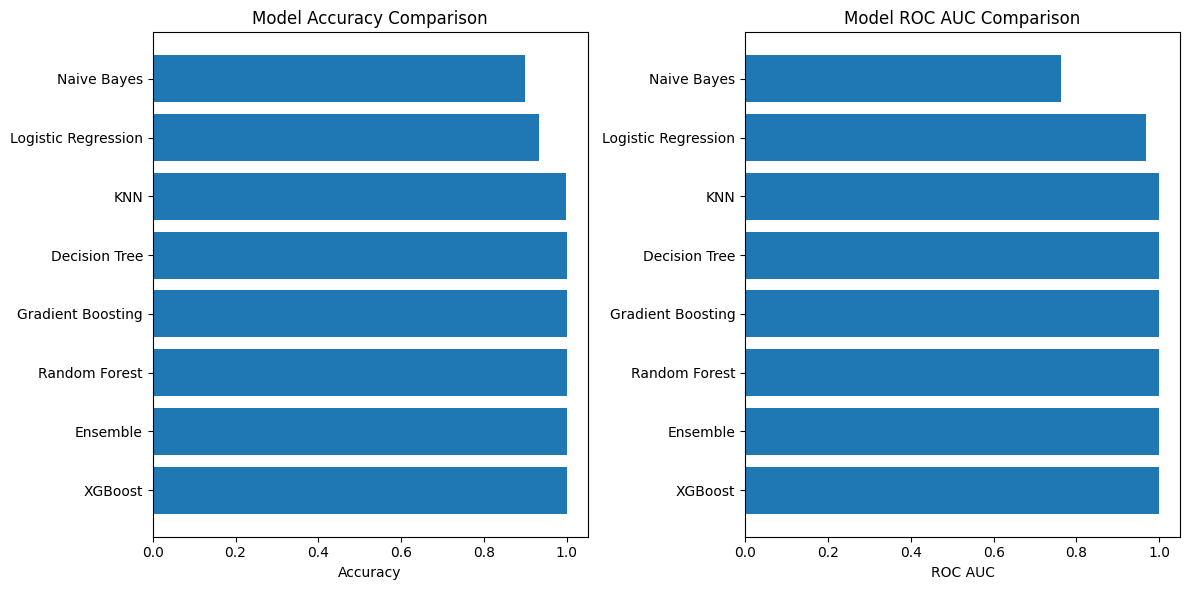

In [14]:
# Add ensemble to results
results['Ensemble'] = {
    'accuracy': accuracy_ensemble,
    'roc_auc': roc_auc_ensemble
}

# Create comparison
comparison_df = pd.DataFrame([
    {'Model': name, 'Accuracy': res['accuracy'], 'ROC AUC': res['roc_auc']}
    for name, res in results.items()
]).sort_values('ROC AUC', ascending=False)

print(f"\n{'='*60}")
print("MODEL COMPARISON SUMMARY")
print(f"{'='*60}")
print(comparison_df.to_string(index=False))

# Visualization
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.barh(comparison_df['Model'], comparison_df['Accuracy'])
plt.xlabel('Accuracy')
plt.title('Model Accuracy Comparison')

plt.subplot(1, 2, 2)
plt.barh(comparison_df['Model'], comparison_df['ROC AUC'])
plt.xlabel('ROC AUC')
plt.title('Model ROC AUC Comparison')

plt.tight_layout()
plt.show()
